  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (3200, 141)
Validation shape: (800, 141)
Test shape: (1000, 141)

Training signal shape: (3200, 140)
Validation signal shape: (800, 140)
Final test signal shape: (1000, 140)

Training labels shape: (3200,)
Validation labels shape: (800,)
Final test labels shape: (1000,)

Training class counts:
[1868 1132   61  124   15]

Validation class counts:
[467 282  16  31   4]

Final test class counts:
[584 353  19  39   5]

Input shape: torch.Size([32, 140])
Target shape: torch.Size([32])
Device: cuda
LSTMClassifier(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=5, bias=True

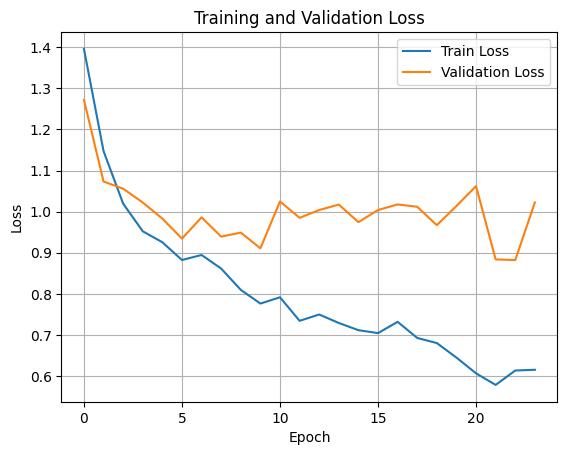

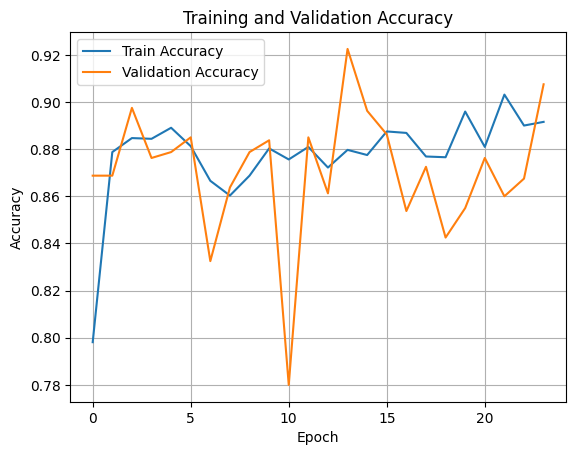

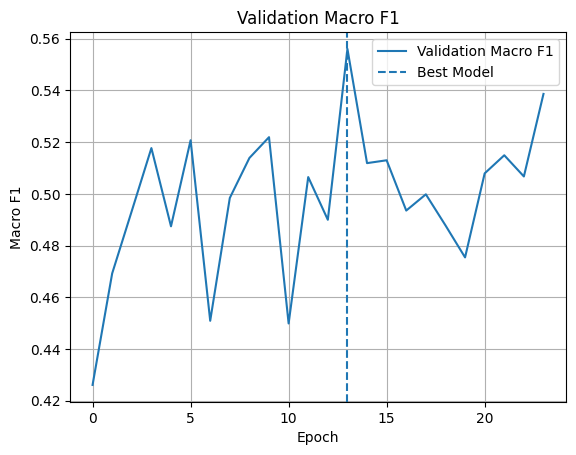


Loaded best model from epoch 14
Best validation Macro F1: 0.5560

FINAL TEST RESULTS
Test accuracy: 0.9210
Balanced accuracy: 0.5708
Macro precision: 0.5653
Macro recall: 0.5708
Macro F1 score: 0.5587
Number of trainable parameters: 50,757

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       584
           1       0.92      0.93      0.93       353
           2       0.38      0.32      0.34        19
           3       0.49      0.44      0.46        39
           4       0.05      0.20      0.08         5

    accuracy                           0.92      1000
   macro avg       0.57      0.57      0.56      1000
weighted avg       0.93      0.92      0.93      1000


Confusion matrix:
[[570   0   2   5   7]
 [  3 327   6  11   6]
 [  2   7   6   1   3]
 [  1  18   1  17   2]
 [  0   2   1   1   1]]


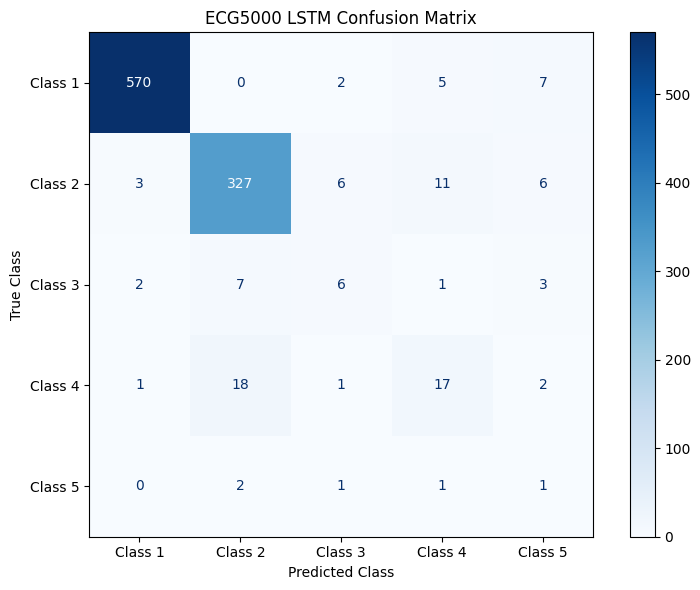

In [2]:
# Install packages not already provided by Colab
!pip install -q git+https://github.com/NX-AI/xlstm.git

from google.colab import drive
drive.mount("/content/drive")

import time
import matplotlib.pyplot as plt
import numpy as np
import torch

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset


### Dataset
class ECGDataset(Dataset):
    def __init__(
        self,
        signal: np.ndarray,
        labels: np.ndarray,
    ):
        self.signal = torch.tensor(
            signal,
            dtype=torch.float32,
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.signal)

    def __getitem__(self, idx):

        # Complete ECG heartbeat
        x = self.signal[idx]

        # ECG class
        y = self.labels[idx]

        return x, y


### LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        output_size: int,
        dropout: float,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            output_size,
        )

    def forward(self, x):

        # x initially:
        # (batch_size, 140)

        # Add feature dimension
        x = x.unsqueeze(-1)

        # x is now:
        # (batch_size, 140, 1)

        lstm_output, _ = self.lstm(x)

        # Use final LSTM timestep
        last_output = lstm_output[:, -1, :]

        # Apply dropout
        last_output = self.dropout(last_output)

        # Predict ECG class
        prediction = self.fc(last_output)

        return prediction


def main():

    ##################################################
    ### LOAD DATA
    ##################################################

    DATA_DIR = "/content/drive/MyDrive/TUBerlin_Data"

    train_path = f"{DATA_DIR}/ECG5000_FOLD_5_TRAIN_3200.txt"
    val_path = f"{DATA_DIR}/ECG5000_FOLD_5_VAL_800.txt"
    test_path = f"{DATA_DIR}/ECG5000_FINAL_TEST_1000.txt"


    train_data = np.loadtxt(train_path)
    val_data = np.loadtxt(val_path)
    test_data = np.loadtxt(test_path)


    print("Train shape:", train_data.shape)
    print("Validation shape:", val_data.shape)
    print("Test shape:", test_data.shape)


    ##################################################
    ### SPLIT SIGNALS AND LABELS
    ##################################################

    # First column = class label
    train_labels = train_data[:, 0].astype(int)
    val_labels = val_data[:, 0].astype(int)
    test_labels = test_data[:, 0].astype(int)


    # Remaining columns = ECG waveform
    train_signal = train_data[:, 1:]
    val_signal = val_data[:, 1:]
    test_signal = test_data[:, 1:]


    ##################################################
    ### CHANGE LABELS FROM 1-5 TO 0-4
    ##################################################

    train_labels = train_labels - 1
    val_labels = val_labels - 1
    test_labels = test_labels - 1


    ##################################################
    ### CHECK DATA
    ##################################################

    print("\nTraining signal shape:", train_signal.shape)
    print("Validation signal shape:", val_signal.shape)
    print("Final test signal shape:", test_signal.shape)

    print("\nTraining labels shape:", train_labels.shape)
    print("Validation labels shape:", val_labels.shape)
    print("Final test labels shape:", test_labels.shape)

    print("\nTraining class counts:")
    print(np.bincount(train_labels))

    print("\nValidation class counts:")
    print(np.bincount(val_labels))

    print("\nFinal test class counts:")
    print(np.bincount(test_labels))


    ##################################################
    ### SCALE DATA
    ##################################################

    scaler = StandardScaler()

    # Fit scaler ONLY on training data
    scaler.fit(train_signal)


    train_signal_scaled = scaler.transform(
        train_signal
    ).astype(np.float32)


    val_signal_scaled = scaler.transform(
        val_signal
    ).astype(np.float32)


    test_signal_scaled = scaler.transform(
        test_signal
    ).astype(np.float32)


    ##################################################
    ### CREATE DATASETS
    ##################################################

    train_dataset = ECGDataset(
        signal=train_signal_scaled,
        labels=train_labels,
    )

    val_dataset = ECGDataset(
        signal=val_signal_scaled,
        labels=val_labels,
    )

    test_dataset = ECGDataset(
        signal=test_signal_scaled,
        labels=test_labels,
    )


    ##################################################
    ### CREATE DATALOADERS
    ##################################################

    bs = 32


    train_loader = DataLoader(
        train_dataset,
        batch_size=bs,
        shuffle=True,
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=bs,
        shuffle=False,
    )


    test_loader = DataLoader(
        test_dataset,
        batch_size=bs,
        shuffle=False,
    )


    x_batch, y_batch = next(iter(train_loader))

    print("\nInput shape:", x_batch.shape)
    print("Target shape:", y_batch.shape)


    ##################################################
    ### DEVICE
    ##################################################

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print("Device:", device)


    ##################################################
    ### INITIALIZE MODEL
    ##################################################

    # One ECG amplitude at each time step
    input_size = 1

    # Five ECG classes
    output_size = 5

    hidden_size = 64
    num_layers = 2
    dropout = 0.1


    model = LSTMClassifier(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        dropout=dropout,
    ).to(device)


    print(model)

    ##################################################
    ### NUMBER OF TRAINABLE PARAMETERS
    ##################################################

    trainable_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"Number of trainable parameters: "
        f"{trainable_parameters:,}"
    )
    ##################################################
    ### CLASS WEIGHTS
    ##################################################

    class_counts = np.bincount(train_labels)

    print("Training class counts:", class_counts)


    class_weights = len(train_labels) / (
        len(class_counts) * class_counts
    )


    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float32,
    ).to(device)


    print("Class weights:", class_weights)


    ##################################################
    ### LOSS FUNCTION
    ##################################################

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )


    ##################################################
    ### OPTIMIZER
    ##################################################

    lr = 0.001


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )


    ##################################################
    ### TRAINING SETTINGS
    ##################################################

    epochs = 100

    # Number of epochs allowed without improvement
    patience = 10


    best_val_f1 = 0.0
    best_epoch = 0

    epochs_without_improvement = 0


    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    val_f1_scores = []
    time_per_epoch = []

    ##################################################
    ### TRAINING LOOP
    ##################################################

    for epoch in range(epochs):

        ### Start timing epoch
        start_time = time.time()

        ##################################################
        ### TRAINING
        ##################################################

        model.train()

        train_loss = 0.0

        train_correct = 0
        train_total = 0


        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(x_batch)

            loss = criterion(
                predictions,
                y_batch,
            )

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

            predicted_class = torch.argmax(
                predictions,
                dim=1,
            )

            train_correct += (
                predicted_class == y_batch
            ).sum().item()

            train_total += y_batch.size(0)


        train_loss /= len(train_loader)

        train_accuracy = (
            train_correct / train_total
        )

        train_losses.append(train_loss)

        train_accuracies.append(
            train_accuracy
        )


        ##################################################
        ### VALIDATION
        ##################################################

        model.eval()

        val_loss = 0.0

        val_correct = 0
        val_total = 0

        val_predictions = []
        val_targets = []


        with torch.no_grad():

            for x_batch, y_batch in val_loader:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(x_batch)

                loss = criterion(
                    predictions,
                    y_batch,
                )

                val_loss += loss.item()

                predicted_class = torch.argmax(
                    predictions,
                    dim=1,
                )

                val_correct += (
                    predicted_class == y_batch
                ).sum().item()

                val_total += y_batch.size(0)

                val_predictions.extend(
                    predicted_class.cpu().numpy()
                )

                val_targets.extend(
                    y_batch.cpu().numpy()
                )


        val_loss /= len(val_loader)

        val_accuracy = (
            val_correct / val_total
        )

        val_predictions = np.array(
            val_predictions
        )

        val_targets = np.array(
            val_targets
        )


        ### Validation Macro F1

        val_f1 = f1_score(
            val_targets,
            val_predictions,
            average="macro",
            zero_division=0,
        )


        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_f1_scores.append(val_f1)


        ##################################################
        ### EARLY STOPPING
        ##################################################

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1

            best_epoch = epoch + 1

            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                "best_lstm_model.pth",
            )

        else:

            epochs_without_improvement += 1


        ##################################################
        ### EPOCH TIME
        ##################################################

        end_time = time.time()

        epoch_time = end_time - start_time

        time_per_epoch.append(epoch_time)


        ##################################################
        ### PRINT EPOCH RESULTS
        ##################################################

        print(
            f"Epoch: {epoch + 1:3d} | "
            f"Train loss: {train_loss:.6f} | "
            f"Val loss: {val_loss:.6f} | "
            f"Train accuracy: {train_accuracy:.4f} | "
            f"Val accuracy: {val_accuracy:.4f} | "
            f"Val Macro F1: {val_f1:.4f} | "
            f"Best F1: {best_val_f1:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )


        ##################################################
        ### STOP TRAINING
        ##################################################

        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch "
                f"{epoch + 1}"
            )

            print(
                f"Best model was from epoch "
                f"{best_epoch}"
            )

            break

    ##################################################
    ### AVERAGE TIME PER EPOCH
    ##################################################

    average_time_per_epoch = (
        sum(time_per_epoch) / len(time_per_epoch)
    )

    print(
        f"\nAverage time per epoch: "
        f"{average_time_per_epoch:.2f}s"
    )

    ##################################################
    ### PLOT TRAINING + VALIDATION LOSS
    ##################################################

    plt.figure()


    plt.plot(
        train_losses,
        label="Train Loss",
    )


    plt.plot(
        val_losses,
        label="Validation Loss",
    )


    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        "Training and Validation Loss"
    )


    plt.grid(True)
    plt.legend()

    plt.show()


    ##################################################
    ### PLOT TRAINING + VALIDATION ACCURACY
    ##################################################

    plt.figure()


    plt.plot(
        train_accuracies,
        label="Train Accuracy",
    )


    plt.plot(
        val_accuracies,
        label="Validation Accuracy",
    )


    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        "Training and Validation Accuracy"
    )


    plt.grid(True)
    plt.legend()

    plt.show()


    ##################################################
    ### PLOT VALIDATION MACRO F1
    ##################################################

    plt.figure()


    plt.plot(
        val_f1_scores,
        label="Validation Macro F1",
    )


    plt.axvline(
        x=best_epoch - 1,
        linestyle="--",
        label="Best Model",
    )


    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")

    plt.title(
        "Validation Macro F1"
    )


    plt.grid(True)
    plt.legend()

    plt.show()


    ##################################################
    ### LOAD BEST MODEL
    ##################################################

    best_model = LSTMClassifier(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        dropout=dropout,
    ).to(device)


    best_model.load_state_dict(
        torch.load(
            "best_lstm_model.pth",
            map_location=device,
        )
    )


    best_model.eval()


    print(
        f"\nLoaded best model from epoch "
        f"{best_epoch}"
    )


    print(
        f"Best validation Macro F1: "
        f"{best_val_f1:.4f}"
    )


    ##################################################
    ### FINAL TESTING
    ##################################################

    test_predictions = []
    test_targets = []


    with torch.no_grad():

        for x_batch, y_batch in test_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = best_model(
                x_batch
            )


            predicted_class = torch.argmax(
                predictions,
                dim=1,
            )


            test_predictions.extend(
                predicted_class.cpu().numpy()
            )


            test_targets.extend(
                y_batch.cpu().numpy()
            )


    test_predictions = np.array(
        test_predictions
    )


    test_targets = np.array(
        test_targets
    )


    ##################################################
    ### FINAL TEST METRICS
    ##################################################
    balanced_accuracy = balanced_accuracy_score(
        test_targets,
        test_predictions,
    )
    accuracy = accuracy_score(
        test_targets,
        test_predictions,
    )


    macro_precision = precision_score(
        test_targets,
        test_predictions,
        average="macro",
        zero_division=0,
    )


    macro_recall = recall_score(
        test_targets,
        test_predictions,
        average="macro",
        zero_division=0,
    )


    macro_f1 = f1_score(
        test_targets,
        test_predictions,
        average="macro",
        zero_division=0,
    )


    print("\nFINAL TEST RESULTS")


    print(
        f"Test accuracy: "
        f"{accuracy:.4f}"
    )

    print(
        f"Balanced accuracy: "
        f"{balanced_accuracy:.4f}"
    )

    print(
        f"Macro precision: "
        f"{macro_precision:.4f}"
    )


    print(
        f"Macro recall: "
        f"{macro_recall:.4f}"
    )


    print(
        f"Macro F1 score: "
        f"{macro_f1:.4f}"
    )


    print(
        f"Number of trainable parameters: "
        f"{trainable_parameters:,}"
    )


    ##################################################
    ### CLASSIFICATION REPORT
    ##################################################

    print(
        "\nClassification report:"
    )


    print(
        classification_report(
            test_targets,
            test_predictions,
            zero_division=0,
        )
    )


    ##################################################
    ### CONFUSION MATRIX
    ##################################################

    cm = confusion_matrix(
        test_targets,
        test_predictions,
    )


    print(
        "\nConfusion matrix:"
    )


    print(cm)


    ##################################################
    ### PLOT CONFUSION MATRIX
    ##################################################

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Class 1",
            "Class 2",
            "Class 3",
            "Class 4",
            "Class 5",
        ],
    )


    fig, ax = plt.subplots(
        figsize=(8, 6)
    )


    display.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
    )


    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )


    plt.title(
        "ECG5000 LSTM Confusion Matrix"
    )


    plt.tight_layout()

    plt.show()


if __name__ == "__main__":
    main()